PREREQUISITE

Before fitting your logistic regression model via scikit-learn, execute these crucial processing steps on the raw data:
    1.   Audit Null Values: Run [df.isnull().sum()] to identify missing entries prominently found within     the  glucose, education, and totChol features

    2. .Locally Impute: Replace numeric nulls using the column [.median()] to avoid distortions from outliers, or
       use .mode()[0] for binary markers like BPMeds.
       
    3.  Handle Multicollinearity: Calculate a correlation matrix. Ensure sysBP (systolic) and diaBP    (diastolic) blood pressures are not overly correlated, as high collinearity destabilizes logistic regression coefficients.
    
    4. Scale the Continuous Features: Apply StandardScaler to continuous fields like age, totChol, and sysBP. Logistic regression relies on gradient descent/regularization, meaning mismatched feature scales will skew model weights.

The Framingham Heart Study is a long term prospective study of the etiology of cardiovascular disease among a population of free living subjects in the community of Framingham, Massachusetts.

The enclosed dataset is a subset of the data collected as part of the Framingham study and includes laboratory, clinic, questionnaire, and adjudicated event data on 4,434 participants. Participant clinic data was collected during three examination periods, approximately 6 years apart, from roughly 1956 to 1968. Each participant was followed for a total of 24 years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder # for scaling and encoding
from sklearn.model_selection import train_test_split

heart_diagnostic = pd.read_csv('Framingham_heart_study.csv')
heart_diagnostic

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


Given the dataset has many columns, it is a a high-dimensional dataset hence we would need to clean it to remove irrelevant and redundant features using many methods

1. Perform exploratory data analysis
     df.info()                          # check dtypes, nulls

     df.describe()                      # spot constant/near-constant columns
     
     df.isnull().sum().sort_values(ascending=False)  # missing value audit

     Drop columns that are: 1. Constant or near-constant (no predictive value)
                            2. Mostly missing (e.g., >50% null, depending on context)

2. Check for multicollinearity
         Highly correlated features add redundancy without adding information.

3. Feature selection techniques
         process of choosing a subset of the most relevant columns (features) from your dataset, and discarding the rest, before training a model. The goal: keep only the features that actually help predict the target, and drop the ones that add noise, redundancy, or complexity without improving performance.

     a). Wrapper method -> Repeatedly trains the model, removes the weakest feature, and repeats until only  n remain.



In [2]:
heart_diagnostic.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [3]:
heart_diagnostic.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [4]:
# CHECKING THE COMPOSITION OF THE TARGET VALUE
heart_diagnostic['TenYearCHD'].unique()

array([0, 1])

In [5]:
# CHECKING IF THERE ARE ANY DUPLICATES AND REMOVING THEM

print("No. of duplicated values are: ",heart_diagnostic.duplicated().sum())

No. of duplicated values are:  0


In [6]:
# CHECKING THE NO. OF NULL VALUES IN THE FEATURES
print(heart_diagnostic.isnull().sum(),"\n")

# FILLING THE NULL VALUES WITH THE MEDIAN, MODE AND MEAN VALUES
heart_diagnostic['education'] = heart_diagnostic['education'].fillna(heart_diagnostic['education'].median())
heart_diagnostic['cigsPerDay'] = heart_diagnostic['cigsPerDay'].fillna(heart_diagnostic['cigsPerDay'].median())
heart_diagnostic['BPMeds'] = heart_diagnostic['BPMeds'].fillna(heart_diagnostic['BPMeds'].median())
heart_diagnostic['totChol'] = heart_diagnostic['totChol'].fillna(heart_diagnostic['totChol'].median())
heart_diagnostic['heartRate'] = heart_diagnostic['heartRate'].fillna(heart_diagnostic['heartRate'].median())
heart_diagnostic['BMI'] = heart_diagnostic['BMI'].fillna(heart_diagnostic['BMI'].median())
heart_diagnostic['glucose'] = heart_diagnostic['glucose'].fillna(heart_diagnostic['glucose'].median())


print(heart_diagnostic.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64 

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [7]:
# RENAMING FIRST COLUMN TO AVOID CONFUSION
heart_diagnostic.rename(columns={"male": "sex"}, inplace=True)

In [8]:
heart_diagnostic

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


REMOVAL OF OUTLIERS IN THE FEARTURES WITH LARGE RANGES

In [9]:
# REMOVAL OF OUTLIERS IN THE AGE FEATURE

Q1_age = heart_diagnostic['age'].quantile(0.25)
Q3_age = heart_diagnostic['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age_bound = Q1_age - 1.5 * IQR_age
upper_age_bound = Q3_age + 1.5 * IQR_age

print(f"Outlier bounds for age: {lower_age_bound:.2f} to {upper_age_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['age'] >= lower_age_bound) & (heart_diagnostic['age'] <= upper_age_bound)]

Outlier bounds for age: 21.00 to 77.00


In [10]:
# REMOVAL OF OUTLIERS IN THE TotalChol FEATURE

Q1_totChol = heart_diagnostic['totChol'].quantile(0.25)
Q3_totChol = heart_diagnostic['totChol'].quantile(0.75)
IQR_totChol = Q3_totChol - Q1_totChol
lower_totChol_bound = Q1_totChol - 1.5 * IQR_totChol
upper_totChol_bound = Q3_totChol + 1.5 * IQR_totChol

print(f"Outlier bounds for Total Cholestrol: {lower_totChol_bound:.2f} to {upper_totChol_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['totChol'] >= lower_totChol_bound) & (heart_diagnostic['totChol'] <= upper_totChol_bound)]

Outlier bounds for Total Cholestrol: 122.00 to 346.00


In [11]:
# REMOVAL OF OUTLIERS IN THE sysBP FEATURE

Q1_sysBP = heart_diagnostic['sysBP'].quantile(0.25)
Q3_sysBP = heart_diagnostic['sysBP'].quantile(0.75)
IQR_sysBP = Q3_sysBP - Q1_sysBP
lower_sysBP_bound = Q1_sysBP - 1.5 * IQR_sysBP
upper_sysBP_bound = Q3_sysBP + 1.5 * IQR_sysBP

print(f"Outlier bounds for sysBP: {lower_sysBP_bound:.2f} to {upper_sysBP_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['sysBP'] >= lower_sysBP_bound) & (heart_diagnostic['sysBP'] <= upper_sysBP_bound)]

Outlier bounds for sysBP: 77.25 to 183.25


In [12]:
# REMOVAL OF OUTLIERS IN THE diaBP FEATURE

Q1_diaBP = heart_diagnostic['diaBP'].quantile(0.25)
Q3_diaBP = heart_diagnostic['diaBP'].quantile(0.75)
IQR_diaBP = Q3_diaBP - Q1_diaBP
lower_diaBP_bound = Q1_diaBP - 1.5 * IQR_diaBP
upper_diaBP_bound = Q3_diaBP + 1.5 * IQR_diaBP

print(f"Outlier bounds for diaBP: {lower_diaBP_bound:.2f} to {upper_diaBP_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['diaBP'] >= lower_diaBP_bound) & (heart_diagnostic['diaBP'] <= upper_diaBP_bound)]

Outlier bounds for diaBP: 52.25 to 110.25


In [13]:
# REMOVAL OF OUTLIERS IN THE BMI FEATURE

Q1_BMI = heart_diagnostic['BMI'].quantile(0.25)
Q3_BMI = heart_diagnostic['BMI'].quantile(0.75)
IQR_BMI = Q3_BMI - Q1_BMI
lower_BMI_bound = Q1_BMI - 1.5 * IQR_BMI
upper_BMI_bound = Q3_BMI + 1.5 * IQR_BMI

print(f"Outlier bounds for BMI: {lower_BMI_bound:.2f} to {upper_BMI_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['BMI'] >= lower_BMI_bound) & (heart_diagnostic['BMI'] <= upper_BMI_bound)]

Outlier bounds for BMI: 15.70 to 35.26


In [14]:
heart_diagnostic.head(6)
#heart_diagnostic['education'].unique()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0


EXPLORATORY DATA ANALYSIS

Text(0.5, 1.0, 'CORRELATION MATRIX FOR HEART DIAGNOSTIC')

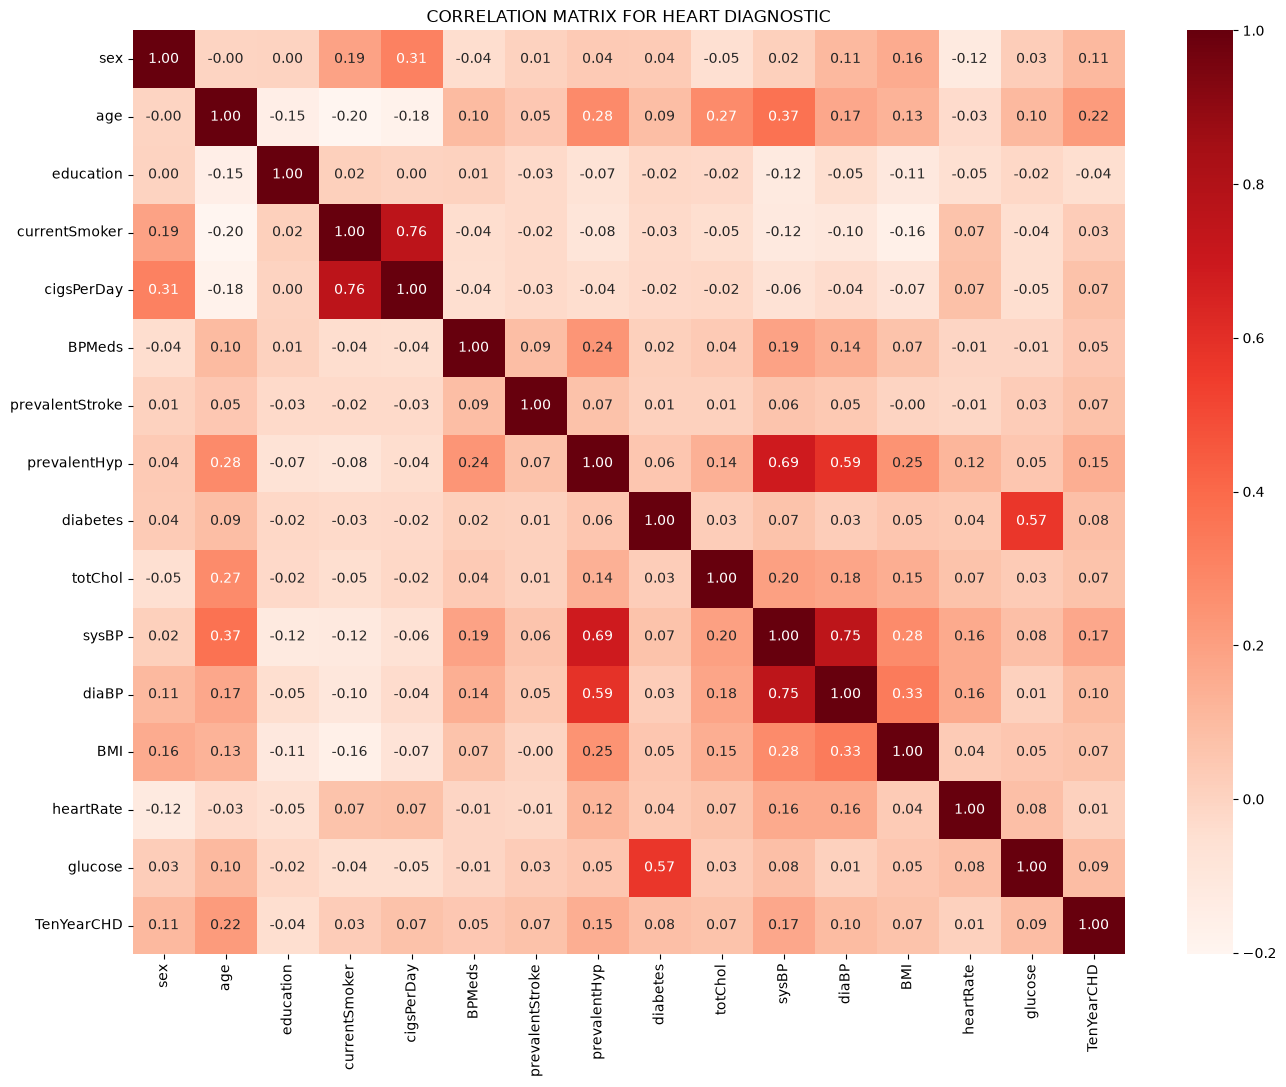

In [15]:
matrix = heart_diagnostic.corr()

plt.figure(figsize=(16, 12))  # increase width/height to fit all rows/columns
sns.heatmap(
    matrix,
    cmap='Reds',
    annot=True,
    fmt='.2f',              # rounds displayed values to 2 decimals, reduces clutter
    annot_kws={'size': 10}   # shrinks number font so it fits in each cell
    
)

plt.title("CORRELATION MATRIX FOR HEART DIAGNOSTIC")

In [16]:
fig = px.histogram(
    heart_diagnostic,
    x='totChol',
    color='prevalentHyp',
    title='Graph of Total Cholesterol showing prevalent hypertension'
)
fig.update_layout(bargap=0.2)
fig.show()

In [17]:
fig = px.histogram(
    heart_diagnostic,
    x='age',
    color='prevalentHyp',
    title='Graph of Ages showing prevalent hypertension'
)
fig.update_layout(bargap=0.2)
fig.show()

In [18]:
fig = px.histogram(
    heart_diagnostic,
    x='glucose',              # glucose on x-axis, not y
    color='diabetes',
    nbins=85,
    barmode='overlay',        # overlay instead of stacking
    histnorm='percent',       # compare shape/proportion, not raw count
    opacity=0.6,
    title='Distribution of Glucose Levels by Diabetic Status'
)
fig.update_layout(bargap=0.5)
fig.show()

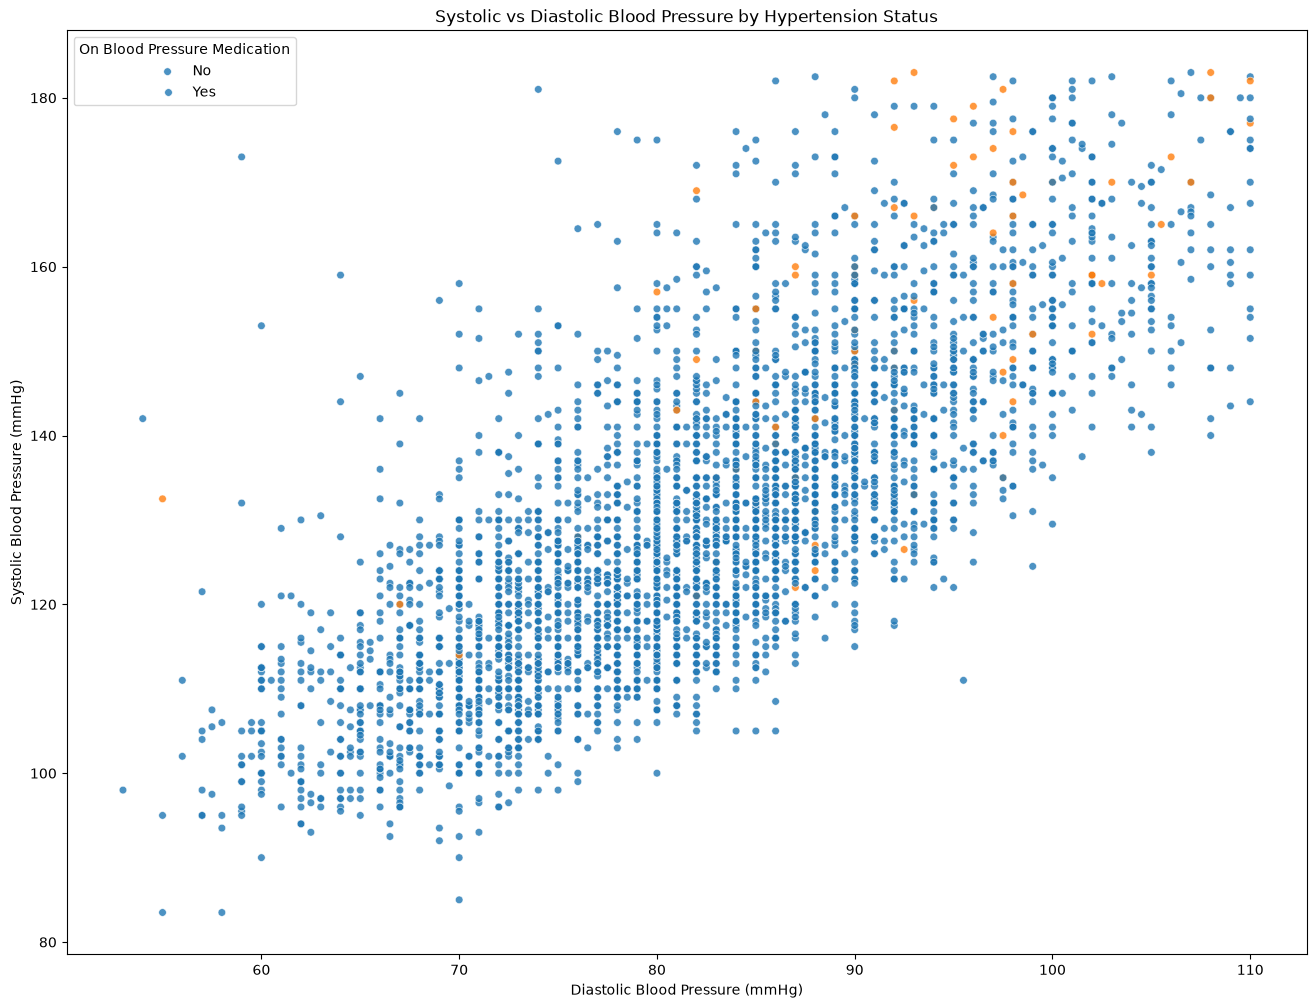

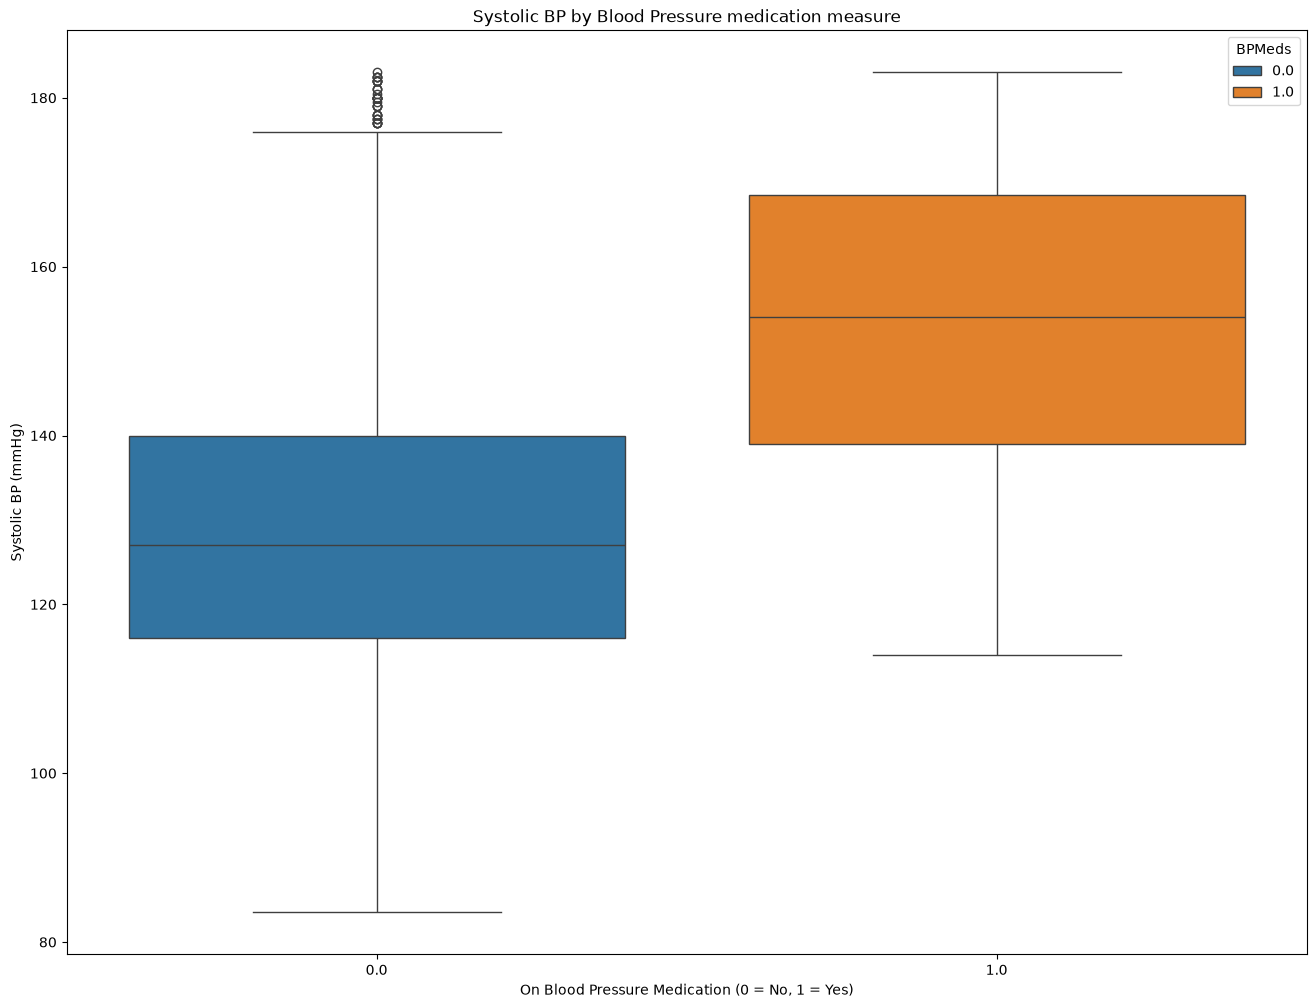

In [19]:
# VISUALIZING THE RELATIONSHIP BETWEEN  SYSTOLIC BLOOD PRESSURE AND DIASTOLIC BLOOD PRESSURE
fig = px.scatter(
    heart_diagnostic,
    x='diaBP',
    y='sysBP',
    color='BPMeds',
    title='Average Systolic BP against Diastolic BP and Blood Pressure medication'
)
fig.show()

plt.figure(figsize=(16, 12)) 
sns.scatterplot(
    x='diaBP',
    y='sysBP',
    data=heart_diagnostic,
    hue='BPMeds',
    s=30,
    alpha=0.8
)
plt.xlabel('Diastolic Blood Pressure (mmHg)')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.title('Systolic vs Diastolic Blood Pressure by Hypertension Status')
plt.legend(title='On Blood Pressure Medication', labels=['No', 'Yes'])
plt.show()

plt.figure(figsize=(16, 12)) 
sns.boxplot(x='BPMeds', y='sysBP', hue='BPMeds',data=heart_diagnostic)
plt.xlabel('On Blood Pressure Medication (0 = No, 1 = Yes)')
plt.ylabel('Systolic BP (mmHg)')
plt.title('Systolic BP by Blood Pressure medication measure')
plt.show()

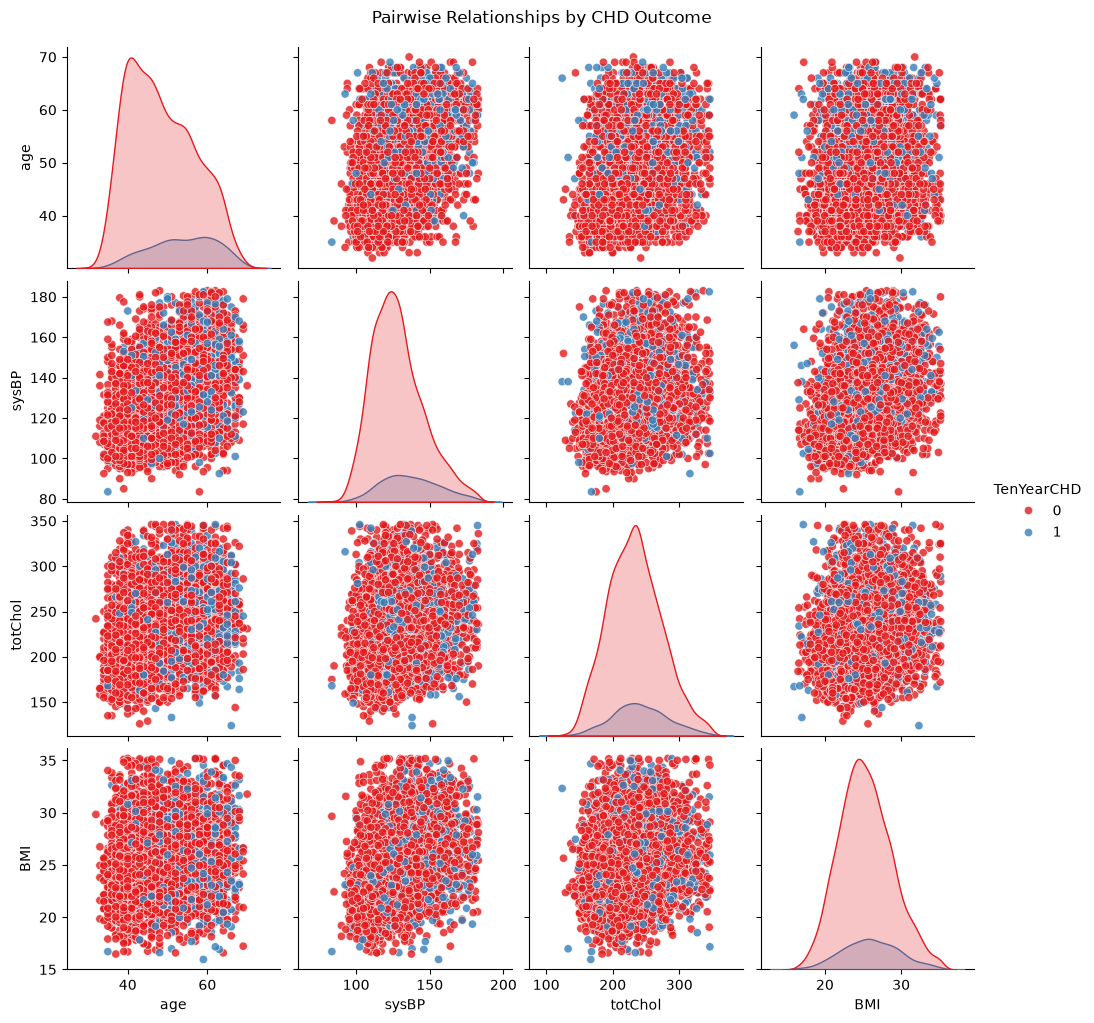

In [20]:
subset = heart_diagnostic[['age', 'sysBP', 'totChol', 'BMI', 'TenYearCHD']]
sns.pairplot(subset, hue='TenYearCHD', diag_kind='kde', palette='Set1', plot_kws={'alpha': 0.8})
plt.suptitle("Pairwise Relationships by CHD Outcome", y=1.02)
plt.show()

In [21]:

fig = px.scatter(
    heart_diagnostic, 
    x='sysBP', 
    y='diaBP',
    marginal_x='histogram', 
    marginal_y='histogram',
    opacity=0.8, 
    title="Systolic vs Diastolic BP with Marginals")
fig.update_layout(bargap=0.5)
fig.show()

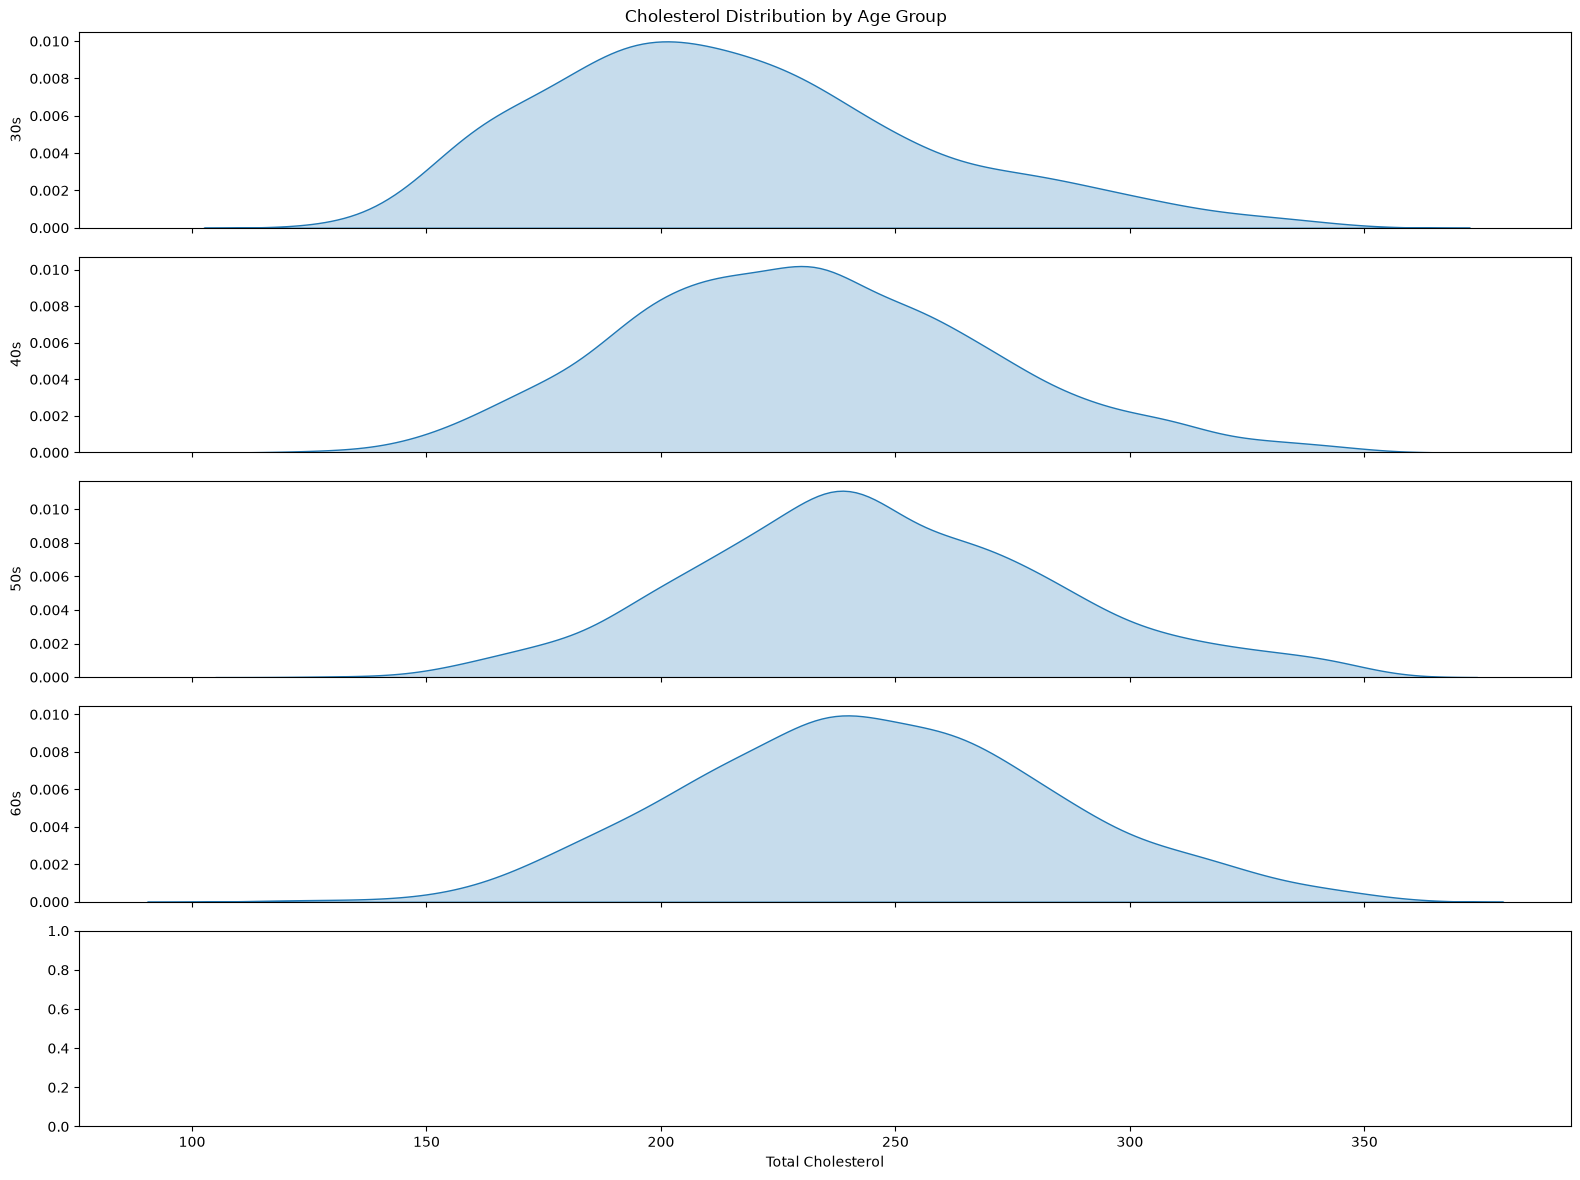

In [22]:
age_bin = pd.cut(heart_diagnostic['age'], bins=[30, 40, 50, 60, 70, 80], labels=['30s','40s','50s','60s','70s'])

fig, axes = plt.subplots(len(age_bin.cat.categories), 1, figsize=(16, 12), sharex=True)
for ax, (label, group) in zip(axes, heart_diagnostic.groupby(age_bin, observed=True)):
    sns.kdeplot(group['totChol'], ax=ax, fill=True)
    ax.set_ylabel(label)
plt.xlabel('Total Cholesterol')
plt.suptitle("Cholesterol Distribution by Age Group")
plt.tight_layout()
plt.show()

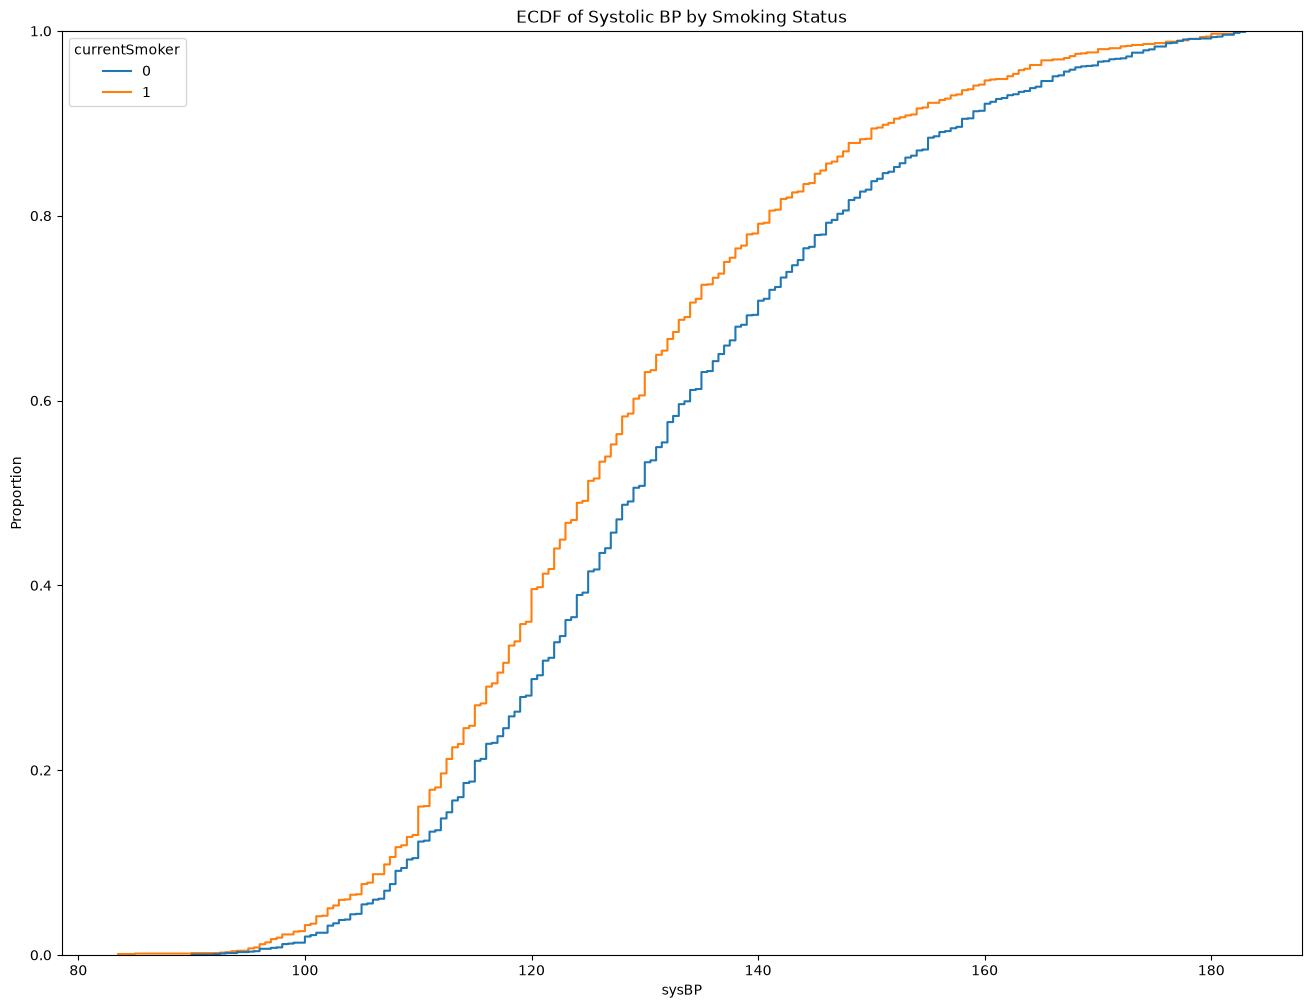

In [23]:

plt.figure(figsize=(16, 12)) 
sns.ecdfplot(data=heart_diagnostic, x='sysBP', hue='currentSmoker')

plt.title("ECDF of Systolic BP by Smoking Status")
plt.show()

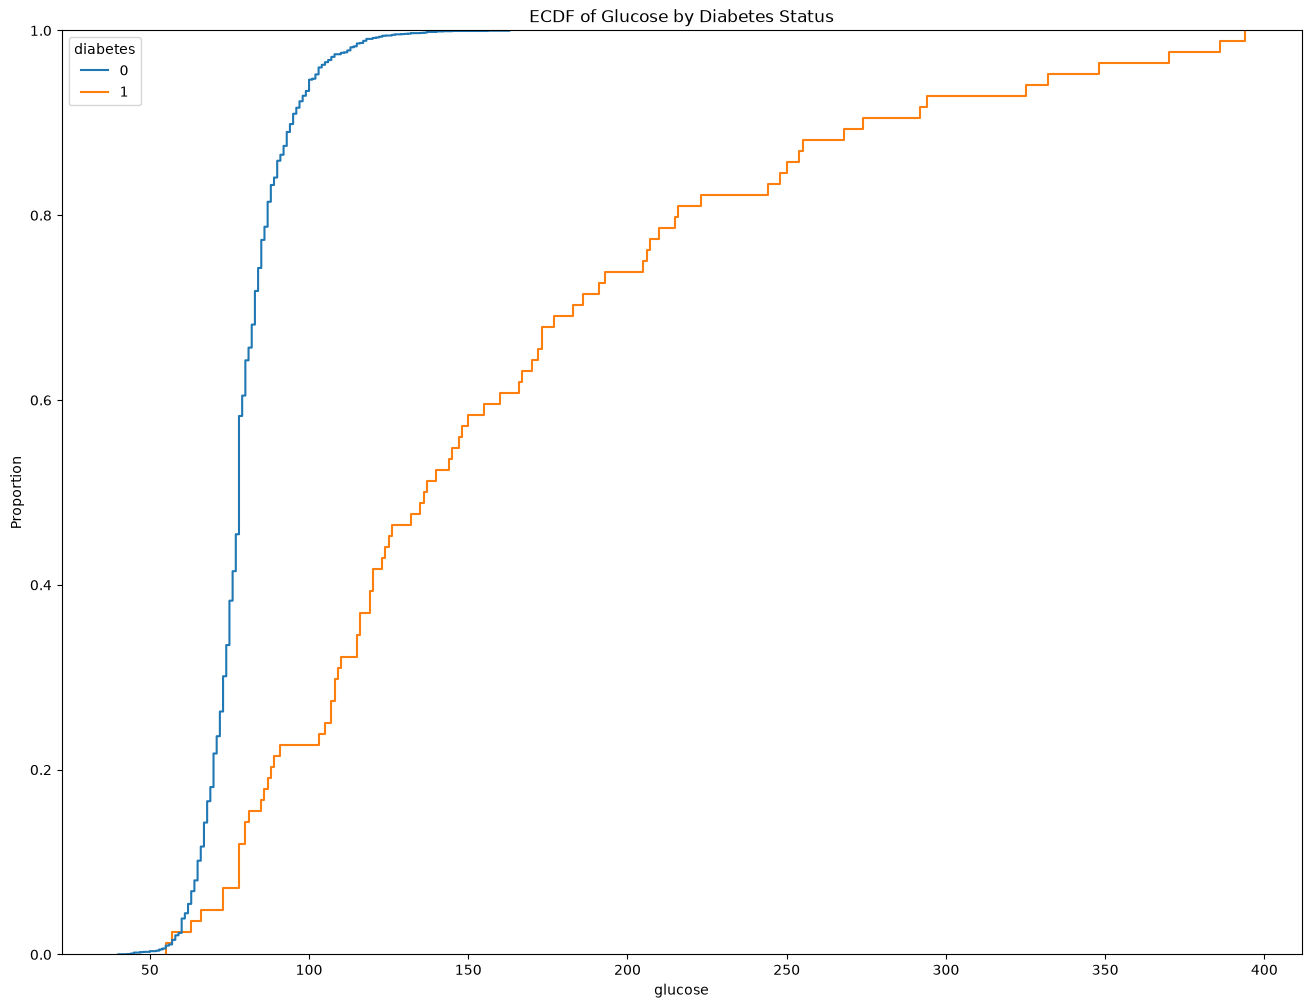

In [24]:
plt.figure(figsize=(16,12))
sns.ecdfplot(data=heart_diagnostic, x='glucose', hue='diabetes')
plt.title("ECDF of Glucose by Diabetes Status")
plt.show()

NOTES ON TRAINING, VALIDATION, AND TEST SETS

When building a real world machine learning model one needs to split the dataset into three parts:

1. Training set -> used to train the model; compute the loss and adjust the models weights using an optimization technique

2. Validation set -> used to evaluate the model during training, tune the models hyperparameters(Optimization Technique, reqularization etc) and pick the best version of the model. picking a good validation set is essential for training models that generalise well

3.  Test set -> used to compare different models or approachesand report the model's final accuracy. For many datasets, test sets are usually provided separately. The test set should reflect the kind of data the model will encounter in the real world as closely as possible.

In [25]:
heart_diagnostic.head(10)

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [26]:
# SPLITTING THE heart_diagnostic DATASET INTO THE TRAINING, VALIDATION AND TESTING SECTIONS

# SPLITTING IT FIRST INTO TRAINING SET AND TEST SET FIRST (80%- training and validation, 20%- testing)
train_valid_df,  test_df = train_test_split(heart_diagnostic, test_size=0.2, random_state=42)

# SPLITTING THE CUMMULATIVE TRAINING SET INTO TRAINING AND VALIDATION SETS (75%- training, 25%-validation)
train_df, valid_df = train_test_split(train_valid_df, test_size=0.25, random_state=42)

print('Training dataframe shape: ', train_df.shape, '\n')
print('Validation dataframe shape: ', valid_df.shape, '\n')
print('Testing dataframe shape: ', test_df.shape, '\n')

Training dataframe shape:  (2361, 16) 

Validation dataframe shape:  (787, 16) 

Testing dataframe shape:  (788, 16) 



WHEN USING DATES, IT IS BEST TO SPLIT BASED ON DATE/TIME SO THAT: 

1  Model is trained on data from the past

2  Model is Evaluated(tested) on data from the future

In [27]:
heart_diagnostic.head(10)

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [28]:
matrix

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
sex,1.000000,-0.003736,0.004291,0.191547,0.310931,-0.038873,0.005069,0.040538,0.035001,-0.048391,0.018252,0.105094,0.156429,-0.120086,0.025074,0.105498
age,-0.003736,1.000000,-0.151784,-0.202184,-0.178463,0.099963,0.050598,0.280575,0.087943,0.273777,0.370024,0.171239,0.129309,-0.030255,0.104551,0.216471
education,0.004291,-0.151784,1.000000,0.015091,0.002418,0.006800,-0.027790,-0.069686,-0.017714,-0.020267,-0.120477,-0.046383,-0.112399,-0.049437,-0.018546,-0.043677
currentSmoker,0.191547,-0.202184,0.015091,1.000000,0.758908,-0.042044,-0.024860,-0.084816,-0.025513,-0.046626,-0.115272,-0.100975,-0.164465,0.066509,-0.044993,0.030546
cigsPerDay,0.310931,-0.178463,0.002418,0.758908,1.000000,-0.042978,-0.027214,-0.041403,-0.022128,-0.015237,-0.061796,-0.037006,-0.072283,0.074967,-0.047097,0.070391
BPMeds,-0.038873,0.099963,0.006800,-0.042044,-0.042978,1.000000,0.087646,0.237234,0.015743,0.038341,0.188075,0.144464,0.066313,-0.007563,-0.009616,0.050115
prevalentStroke,0.005069,0.050598,-0.027790,-0.024860,-0.027214,0.087646,1.000000,0.072832,0.013317,0.010755,0.064781,0.046164,-0.001093,-0.010125,0.028973,0.071180
prevalentHyp,0.040538,0.280575,-0.069686,-0.084816,-0.041403,0.237234,0.072832,1.000000,0.055969,0.139016,0.686344,0.588213,0.248358,0.119100,0.052900,0.149589
diabetes,0.035001,0.087943,-0.017714,-0.025513,-0.022128,0.015743,0.013317,0.055969,1.000000,0.026346,0.068430,0.026407,0.054119,0.042970,0.568860,0.082628
totChol,-0.048391,0.273777,-0.020267,-0.046626,-0.015237,0.038341,0.010755,0.139016,0.026346,1.000000,0.199736,0.178262,0.149258,0.069707,0.033317,0.068487


In [29]:
# CODE TO CHECK THE INPUT FEATURES THAT HAVE A CORRELATION OF =>0.02 WITH THE TARGET FEATURE
input_cols =  ['sex','age','currentSmoker','cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
target_col = 'TenYearCHD'



In [30]:
# CREATING INPUTS AND TARGETS FOR THE TRAINING, VALIDATION AND TEST SETS FOR FURTHER PROCESSING AND MODEL TRAINING
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()

validation_inputs = valid_df[input_cols].copy()
validation_target = valid_df[target_col].copy()

testing_inputs = test_df[input_cols].copy()
testing_target = test_df[target_col].copy()

IN A CASE OF FILLING IN MISSING VALUES, ONE CAN USE THE LIBRARY

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'mean'/ 'median'/ 'mode')

SCALING OF VALUES FROM (0,1) TO LEVEL THE OPTIMIZATION

In [31]:
from sklearn.preprocessing import MinMaxScaler 

scaler = MinMaxScaler()
scaler.fit(heart_diagnostic[input_cols])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](14,)","[ 1. , 70. , 1. ,..., 35.2,143. ,394. ]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](14,)","[ 0. ,32. , 0. ,...,15.96,44. ,40. ]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](14,)","[ 1. , 38. , 1. ,..., 19.24, 99. ,354. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['sex','age','currentSmoker',...,'BMI','heartRate','glucose']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](14,)","[ 0. ,-0.84, 0. ,...,-0.83,-0.44,-0.11]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,3936


In [32]:
# Actual scaling of the inputs in the range (0,1)

train_inputs[input_cols] = scaler.transform(train_inputs[input_cols])
validation_inputs[input_cols] = scaler.transform(validation_inputs[input_cols])
testing_inputs[input_cols] = scaler.transform(testing_inputs[input_cols])

SAVING PROCESSED DATA TO DISK

In [33]:
# Saving into csv format
train_inputs.to_csv('train_inputs.csv')
validation_inputs.to_csv('valid_inputs.csv')
testing_inputs.to_csv('test_inputs.csv')

pd.DataFrame(train_target).to_csv('train_target.csv')
pd.DataFrame(validation_target).to_csv('valid_target.csv')
pd.DataFrame(testing_target).to_csv('test_target.csv')

# TRAINING THE LOGISTIC REGRESSION MODEL

In [34]:
# Initialization of the logistic regression model

logistics_model = LogisticRegression(solver='liblinear')

In [35]:
#  Training the logistic regression model
logistics_model.fit(train_inputs, train_target)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some pen

In [36]:
# PRINTING OUT THE COEFFICIENTS(WEIGHTS) AND THE INTERCEPT
# printing the weights in a list
print("The weights are: ",logistics_model.coef_.tolist(),'\n')
# printing the coefficients
print("The Intercept is: ",logistics_model.intercept_)

The weights are:  [[0.6406928331874853, 2.077514372336837, -0.0873473917467659, 1.1655020266821712, 0.19337607392908565, 0.9308537410713175, 0.2868332629474341, 0.8642278377121048, 0.09179388226637515, 1.215341690978435, -0.24986128044511818, -0.27301455787698, 0.19709650227654363, 0.4410365650408693]] 

The Intercept is:  [-3.90988771]


In [37]:
train_inputs

,sex,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
1511,0.0,0.157895,0.0,0.000000,0.0,0.0,0.0,0.0,0.590090,0.417085,0.561404,0.368503,0.282828,0.093220
1278,1.0,0.552632,1.0,0.428571,0.0,0.0,0.0,0.0,0.581081,0.376884,0.570175,0.652807,0.363636,0.079096
134,0.0,0.473684,1.0,0.214286,0.0,0.0,0.0,0.0,0.117117,0.376884,0.543860,0.661642,0.313131,0.135593
4223,1.0,0.631579,0.0,0.000000,1.0,0.0,1.0,0.0,0.734234,0.658291,0.789474,0.297297,0.464646,0.098870
3527,1.0,0.289474,1.0,0.214286,0.0,0.0,0.0,0.0,0.229730,0.417085,0.403509,0.465696,0.363636,0.155367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351,0.0,0.710526,0.0,0.000000,0.0,0.0,0.0,0.0,0.756757,0.306533,0.543860,0.594075,0.242424,0.090395
3155,1.0,0.263158,1.0,0.428571,0.0,0.0,0.0,0.0,0.657658,0.386935,0.508772,0.745842,0.282828,0.288136
2751,1.0,0.184211,1.0,0.285714,0.0,0.0,0.0,0.0,0.725225,0.366834,0.429825,0.642931,0.515152,0.110169
2057,1.0,0.657895,0.0,0.000000,0.0,0.0,0.0,0.0,0.572072,0.306533,0.385965,0.540021,0.363636,0.090395


In [42]:
# ARRANGING THE WEIGHTS IN A LOGICAL ORDER

weights_df = pd.DataFrame({
    'Feature' : input_cols,
    'Weights' : logistics_model.coef_.tolist()[0]
})


<Axes: xlabel='Weights', ylabel='Feature'>

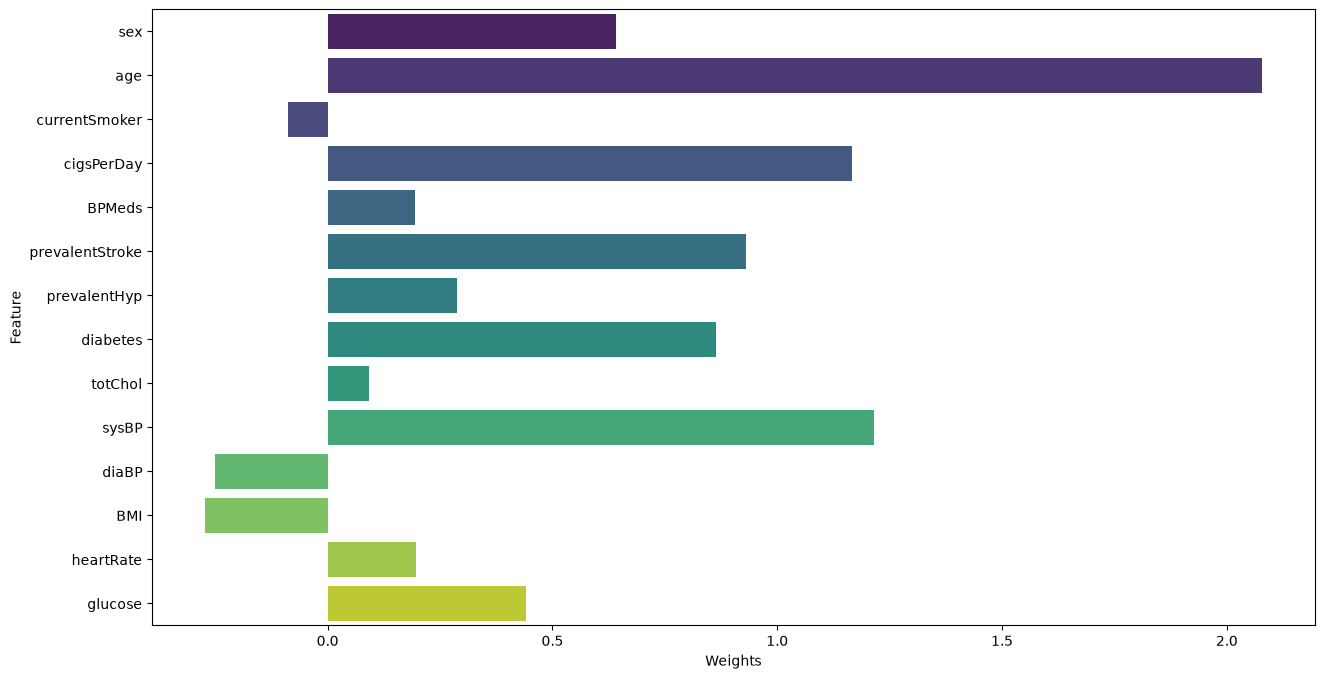

In [48]:
# PLOTTING OUT THE WEIGHTS FOR EACH FEATURE

plt.figure(figsize=(15,8))
sns.barplot(data=weights_df, x='Weights', y='Feature', hue='Feature', palette='viridis', legend=False)

# MAKING PREDICTIONS AND EVALUATING THE MODEL

In [49]:
train_predictions = logistics_model.predict(train_inputs)

In [50]:
train_predictions

array([0, 0, 0, ..., 0, 0, 0], shape=(2361,))

In [51]:
train_target

1511    0
1278    0
134     0
4223    1
3527    0
       ..
1351    0
3155    0
2751    0
2057    0
2494    0
Name: TenYearCHD, Length: 2361, dtype: int64

In [52]:
# CHECKING THE ACCURACY OF THE MODEL

from sklearn.metrics import accuracy_score
accuracy_score(train_target, train_predictions)

0.8661584074544685

WE CAN VISUALISE THE BREAKDOWN CORRECTLY AND INCORRECTLY CLASSIFIED INPUTS USING A CONFUSION MATRIX

In [54]:
# implementation of the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(train_target, train_predictions, normalize='true')

array([[0.99803536, 0.00196464],
       [0.96      , 0.04      ]])

In [57]:
# CREATING A FUNCTION TO PREDICT AND CHECK THE ACCURACY OF THE MODEL

def predict_plot(inputs, targets, name=''):
    predictions = logistics_model.predict(inputs)
    
    accuracy = accuracy_score(targets, predictions)
    print("Accuracy: {:.2f} %".format(accuracy*100))
    
    cf = confusion_matrix(targets, predictions, normalize='true')
    plt.figure(figsize=(16,12))
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    
    return predictions


Accuracy: 86.62 %


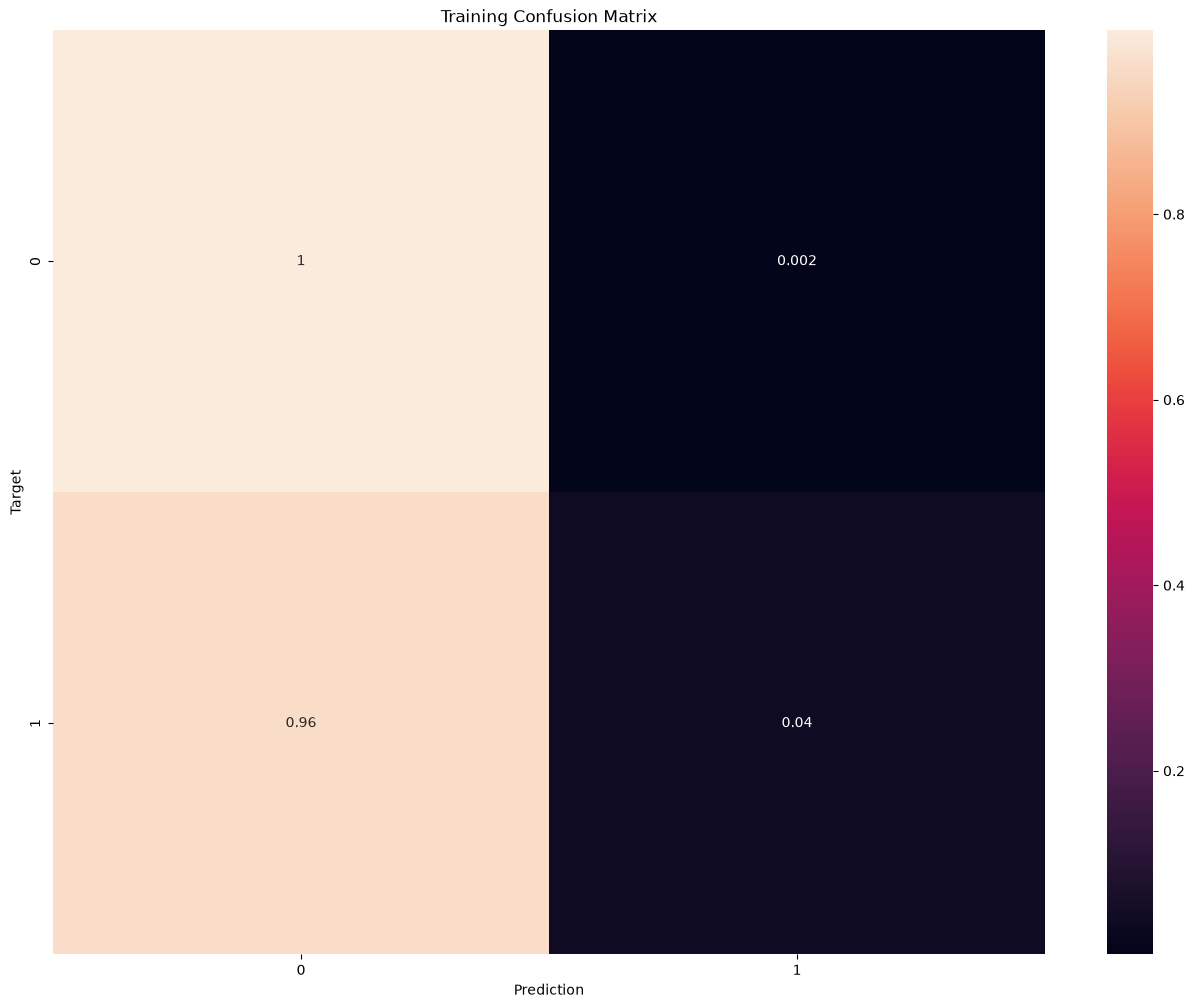

In [58]:
training_predictions = predict_plot(train_inputs, train_target, 'Training')